# AI Act Benchmark: EDA and Data Preparation

Explore labels, text quality, BERT token lengths, and reproducible model splits.

In [3]:
# Colab setup
# Run this cell only when using Google Colab.
import os
from pathlib import Path
from urllib.request import urlretrieve

if Path('/content').exists():
    if not Path('/content/deep-learning-project').exists():
        !git clone https://github.com/Freh-dev/deep-learning-project.git /content/deep-learning-project
    %pip install -q -r /content/deep-learning-project/requirements.txt

    data_folder = Path('/content/deep-learning-project/data/raw')
    data_folder.mkdir(parents=True, exist_ok=True)
    scenarios_file = data_folder / 'scenarios.json'
    if not scenarios_file.exists():
        urlretrieve(
            'https://raw.githubusercontent.com/davidath/ai-act-evaluation-benchmark/main/scenarios.json',
            scenarios_file,
        )

    os.chdir('/content/deep-learning-project')

print('Setup complete')

Setup complete


Rows: 339
Number of classes: 4


,missing_values
role,0
intended_use,0
system_type,0
input_data,0
domain,0
related_articles,0
obligations,0
risk_level,0
text,0
label,0


Duplicate model inputs: 0


,count,fraction
risk_level,,
high-risk,86,25.4%
limited,84,24.8%
minimal,99,29.2%
prohibited,70,20.6%


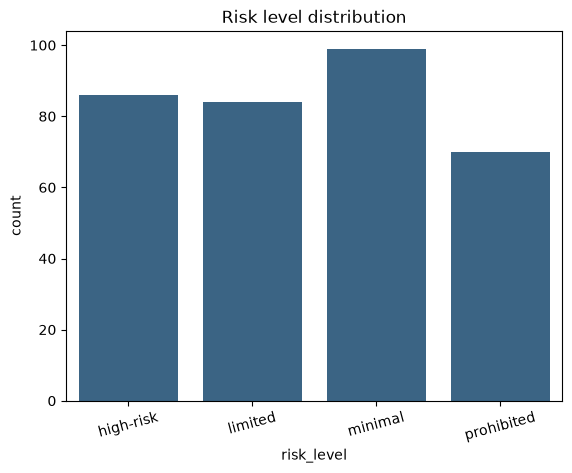

count    339.00
mean      26.67
std        5.83
min       17.00
25%       22.00
50%       25.00
75%       31.00
max       43.00
Name: word_count, dtype: float64

count    339.00
mean      37.52
std        6.80
min       24.00
25%       32.00
50%       36.00
75%       43.00
max       57.00
Name: text, dtype: float64
Inputs over 64 tokens: 0


,train,validation,test
risk_level,,,
high-risk,60,13,13
limited,59,12,13
minimal,69,15,15
prohibited,49,11,10


{'train': 237, 'validation': 51, 'test': 51}


In [4]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from transformers import AutoTokenizer

# Works in Colab and in the local project folder.
PROJECT_ROOT = Path('/content/deep-learning-project')
if not (PROJECT_ROOT / 'data' / 'raw').exists():
    PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'raw').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocess import EXPECTED_LABELS, load_scenarios, split_scenarios

scenarios = load_scenarios(PROJECT_ROOT / 'data' / 'raw' / 'scenarios.json')
print(f'Rows: {len(scenarios):,}')
print(f'Number of classes: {scenarios["risk_level"].nunique()}')
display(scenarios.isna().sum().rename('missing_values').to_frame())
print(f'Duplicate model inputs: {scenarios["text"].duplicated().sum()}')

label_summary = scenarios['risk_level'].value_counts().reindex(EXPECTED_LABELS).rename_axis('risk_level').to_frame('count')
label_summary['fraction'] = label_summary['count'] / len(scenarios)
display(label_summary.style.format({'fraction': '{:.1%}'}))
sns.barplot(data=label_summary.reset_index(), x='risk_level', y='count', order=EXPECTED_LABELS, color='#2f6690')
plt.xticks(rotation=15)
plt.title('Risk level distribution')
plt.show()

scenarios['word_count'] = scenarios['text'].str.split().str.len()
display(scenarios['word_count'].describe().round(2))
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
token_lengths = scenarios['text'].map(lambda value: len(tokenizer.encode(value, add_special_tokens=True)))
print(token_lengths.describe().round(2))
print(f'Inputs over 64 tokens: {(token_lengths > 64).sum()}')

splits = split_scenarios(scenarios)
display(pd.concat({name: split['risk_level'].value_counts().reindex(EXPECTED_LABELS, fill_value=0) for name, split in splits.items()}, axis=1))
print({name: len(split) for name, split in splits.items()})

## Feature overview

The classifier uses the intended use, system type, input data, and domain. The obligations and related articles are kept for later interpretation and are not used as model inputs.

In [5]:
feature_summary = pd.DataFrame({
    'unique_values': scenarios[['role', 'system_type', 'domain']].nunique(),
    'missing_values': scenarios[['role', 'system_type', 'domain']].isna().sum()
})
display(feature_summary)

,unique_values,missing_values
role,2,0
system_type,298,0
domain,112,0


## Risk level by role and domain

These tables show whether the target distribution changes across common categories.

risk_level,high-risk,limited,minimal,prohibited
role,,,,
Deployer,25.4%,24.9%,29.0%,20.7%
Provider,25.3%,24.7%,29.4%,20.6%


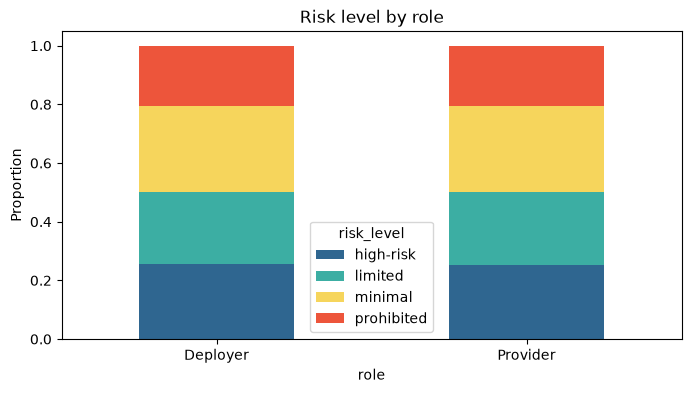

risk_level,high-risk,limited,minimal,prohibited
domain,,,,
Access to and enjoyment of essential private services and essential public services and benefits,12,0,0,0
Biometrics,10,0,0,0
Consumer Technology,0,8,0,0
Education,0,8,4,5
Education and vocational training,10,0,0,0
"Employment, workers’ management and access to self‐employment",10,0,0,0
Entertainment,0,1,3,3
Law enforcement,10,0,0,1
Management and operation of critical infrastructure,9,0,0,0


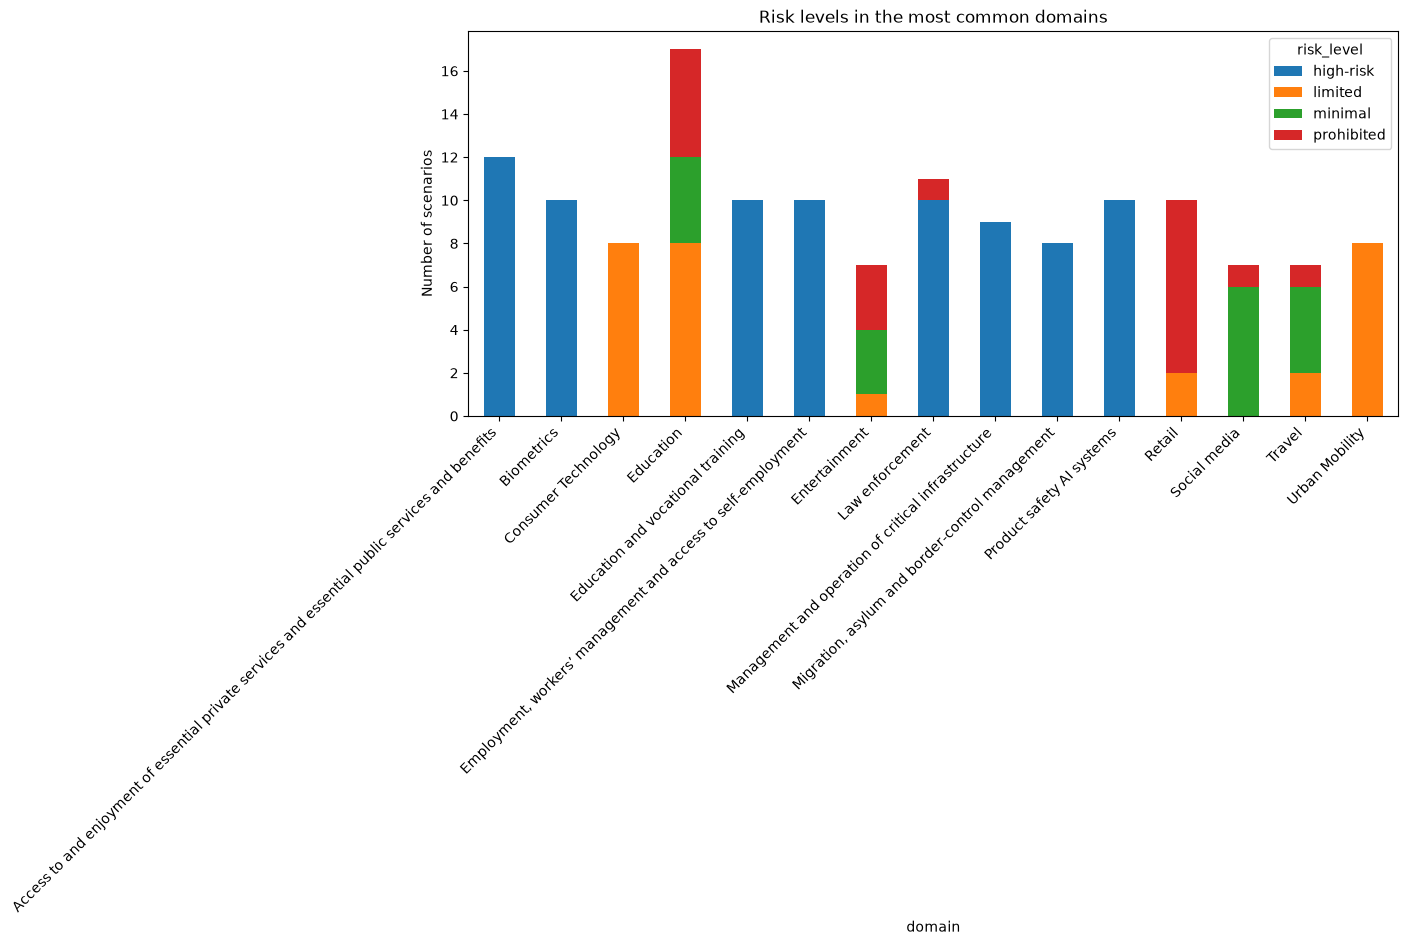

In [6]:
role_risk = pd.crosstab(
    scenarios['role'],
    scenarios['risk_level'],
    normalize='index'
).reindex(columns=EXPECTED_LABELS)

display(role_risk.style.format('{:.1%}'))
role_risk.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#2f6690', '#3caea3', '#f6d55c', '#ed553b'])
plt.ylabel('Proportion')
plt.title('Risk level by role')
plt.xticks(rotation=0)
plt.show()

top_domains = scenarios['domain'].value_counts().head(15).index
domain_data = scenarios[scenarios['domain'].isin(top_domains)]
domain_risk = pd.crosstab(domain_data['domain'], domain_data['risk_level']).reindex(columns=EXPECTED_LABELS, fill_value=0)
display(domain_risk)
domain_risk.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.ylabel('Number of scenarios')
plt.title('Risk levels in the most common domains')
plt.xticks(rotation=45, ha='right')
plt.show()

## Text length by risk level

The model inputs are short, but this checks whether some labels systematically have longer descriptions.

,count,mean,median,min,max
risk_level,,,,,
high-risk,86,31.41,31.0,23,43
limited,84,21.93,22.0,17,35
minimal,99,22.65,23.0,17,30
prohibited,70,32.21,32.0,27,39


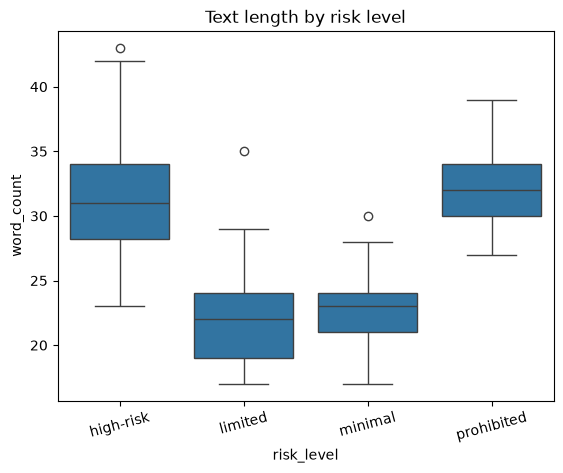

In [7]:
display(
    scenarios.groupby('risk_level')['word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reindex(EXPECTED_LABELS)
    .round(2)
)

sns.boxplot(data=scenarios, x='risk_level', y='word_count', order=EXPECTED_LABELS)
plt.title('Text length by risk level')
plt.xticks(rotation=15)
plt.show()

## Final split check

The validation set is used for model selection. The test set stays untouched until final comparison of XGBoost and BERT.

In [8]:
for name, split in splits.items():
    print(f'{name}: {len(split)} rows')
    display(split['risk_level'].value_counts().reindex(EXPECTED_LABELS, fill_value=0).rename(name))

train: 237 rows


risk_level
high-risk     60
limited       59
minimal       69
prohibited    49
Name: train, dtype: int64

validation: 51 rows


risk_level
high-risk     13
limited       12
minimal       15
prohibited    11
Name: validation, dtype: int64

test: 51 rows


risk_level
high-risk     13
limited       13
minimal       15
prohibited    10
Name: test, dtype: int64

## EDA findings

- The dataset contains 339 labeled scenarios and four risk classes.
- The classes are somewhat imbalanced: `minimal` is the largest class and `prohibited` is the smallest.
- There are no missing required values and no duplicate model text inputs.
- The inputs are short. The longest BERT input is 57 tokens, so `max_length=64` is sufficient and no examples are truncated.
- The stratified split contains 237 training examples, 51 validation examples, and 51 test examples.
- The validation set will be used for model selection, while the test set will be used only for the final XGBoost versus BERT comparison.